In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, ticker

In [2]:
path = '/global/cfs/cdirs/m5214/hbhat512/memorymodel1RDM/deltagpuAMD/sweep/'

In [3]:
alldata = np.zeros((10, 10, 3))

In [4]:
start = 1e-4
end = 1e-2
ratio = np.exp(np.log(end/start)/9)
intensity = start * (ratio**np.arange(10))
print(intensity)

start = 1e-3
end = 2e-2
ratio = np.exp(np.log(end/start)/9)
freq = start * (ratio**np.arange(10))
print(freq)

[0.0001     0.00016681 0.00027826 0.00046416 0.00077426 0.00129155
 0.00215443 0.00359381 0.00599484 0.01      ]
[0.001      0.00139495 0.00194589 0.00271442 0.00378648 0.00528195
 0.00736806 0.01027809 0.01433742 0.02      ]


In [5]:
for i in range(10):
    for j in range(10):
        for k in range(3):
            delay = 100 + 50*k
            freqstr = f"{freq[i]:.6f}"
            istr = f"{intensity[j]:.6f}"
            target_file='fci_h2_6-31gss_0.050000_'+str(delay)+'_'+freqstr+'_'+istr+'_1.txt'
            f = np.loadtxt(path + target_file, skiprows=2, delimiter=',')
            alldata[i, j, k] = f[1]

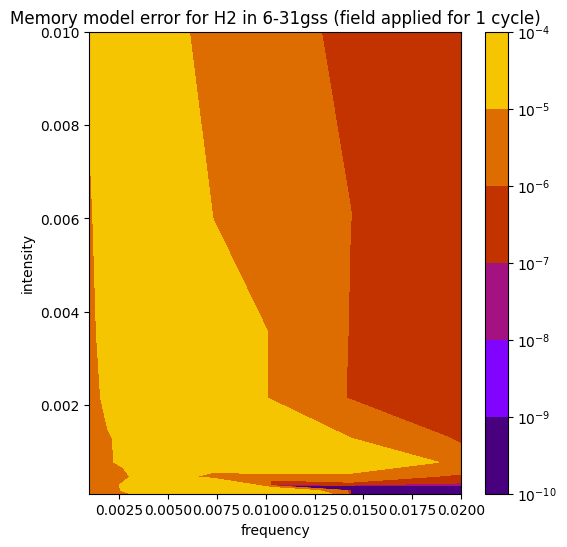

In [15]:
plt.figure(figsize=(6,6))
plt.contourf(freq, intensity, alldata[:,:,1], locator=ticker.LogLocator(), cmap=cm.gnuplot)
plt.xlabel('frequency')
plt.ylabel('intensity')
plt.title('Memory model error for H2 in 6-31gss (field applied for 1 cycle)')
plt.colorbar()
plt.savefig('sweepdelay150.pdf')
plt.show()

In [51]:
alldata[9,9,1]

np.float64(5.358817970150867e-07)

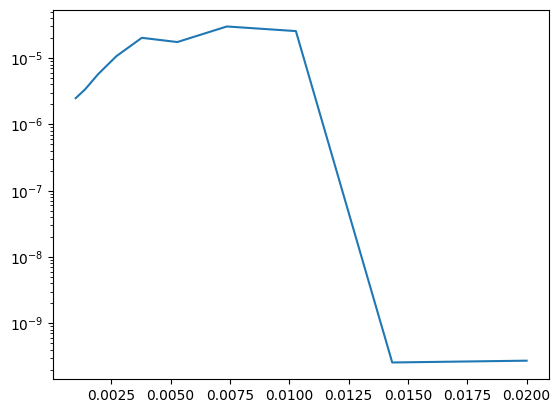

In [25]:
plt.semilogy(freq, alldata[1,:,1])
plt.show()